In [59]:
import pathlib
import sys

import torch
import torch.optim as optim
from fsspec.config import conf

from torch import nn
from torch.cuda import device
from torch.utils.data import DataLoader
from pathlib import Path
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import random_split
from loguru import logger

from src.config.config import Config
from neurostreak.trainer import TrainerNeuroStreak
from neurostreak.dataset import NeuroStreakDataset
from src.data import StreakImageDataset
import numpy as np
import ptwt
import matplotlib.pyplot as plt


In [60]:
config = Config()
config.load_model_config(Path('C:/Users/supervisor.LTCPC-280426-01/PycharmProjects/NeuroStreak/src/config/config.yaml'))
model = config.get_model_from_config()
weights = torch.load('C:/Users/supervisor.LTCPC-280426-01/PycharmProjects/NeuroStreak/scripts/save/24_08_26_neurostreak/model_checkpoin_epoch_5.pt')
model.load_state_dict(weights)

name NeuroStreak_0.0.1
head {'spectral_dim': 64, 'wavelet_dim': 32, 'embedding_dim': 128}
backbone {'hidden_dim': 32, 'num_heads': 8, 'depth': 8}
embedding {'wavelet': 'gaus1', 'max_amp': 101, 'step': 1}
//////////////////////////////////////////////////////////////////////

Конфиг модели успешно загружен


<All keys matched successfully>

In [61]:
model.backbone

NeuroStreakBackbone(
  (wavelet_attention_block): WaveletAttentionBlock(
    (convolution): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 7), stride=(3, 7), padding=(1, 3))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(8, 16, kernel_size=(3, 5), stride=(3, 5), padding=(1, 2))
      (4): ReLU(inplace=True)
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU(inplace=True)
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (embedding_projection): Linear(in_features=1, out_features=1, bias=True)
    (cross_attention): ModuleList(
      (0-7): 8 x CrossAttention(
        (cross_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
      )
    )


In [62]:
path = 'C:/Users/supervisor.LTCPC-280426-01/PycharmProjects/NeuroStreak/data/clean_water_13m/template.npy'
signal = np.load(path)
signal = torch.tensor(signal, dtype=torch.float32)
signal_3 = torch.cat([signal,signal,signal], dim=-1)
scales = torch.arange(1,101, 1, device=signal.device)
coef, freqs = ptwt.cwt(signal_3, scales, wavelet= 'gaus1')
coef = coef[:, len(signal):2*len(signal)]
coef  = coef.to(dtype=torch.float32, device=signal.device)
coef.shape

torch.Size([100, 840])

Text(0.5, 1.0, 'Оригинальный сигнал для clean_water_13m')

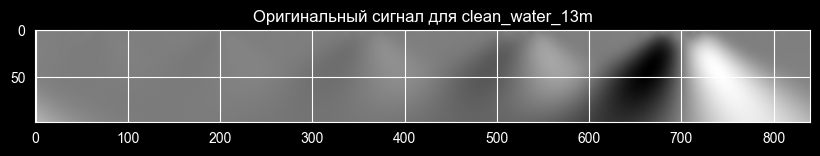

In [63]:
fig = plt.figure(figsize=[10,10])
plt.imshow(coef.numpy(), cmap='gray')
plt.title(f'Оригинальный сигнал для {path.split("/")[-2]}')

На 25.08 для Neurostreak 0.0.1 имеется следующая структура слоев backbone

    (convolution): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 7), stride=(3, 7), padding=(1, 3))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(8, 16, kernel_size=(3, 5), stride=(3, 5), padding=(1, 2))
      (4): ReLU(inplace=True)
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU(inplace=True)
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


In [64]:
conv_layer = model.backbone.wavelet_attention_block.convolution[0]
result_convolution = conv_layer(coef.unsqueeze(dim=0))
weights = conv_layer.weight

print(f'Форма карт признаков после первого слоя: {result_convolution.shape} Форма весов: {weights.shape}, ')

Форма карт признаков после первого слоя: torch.Size([8, 34, 120]) Форма весов: torch.Size([8, 1, 3, 7]), 


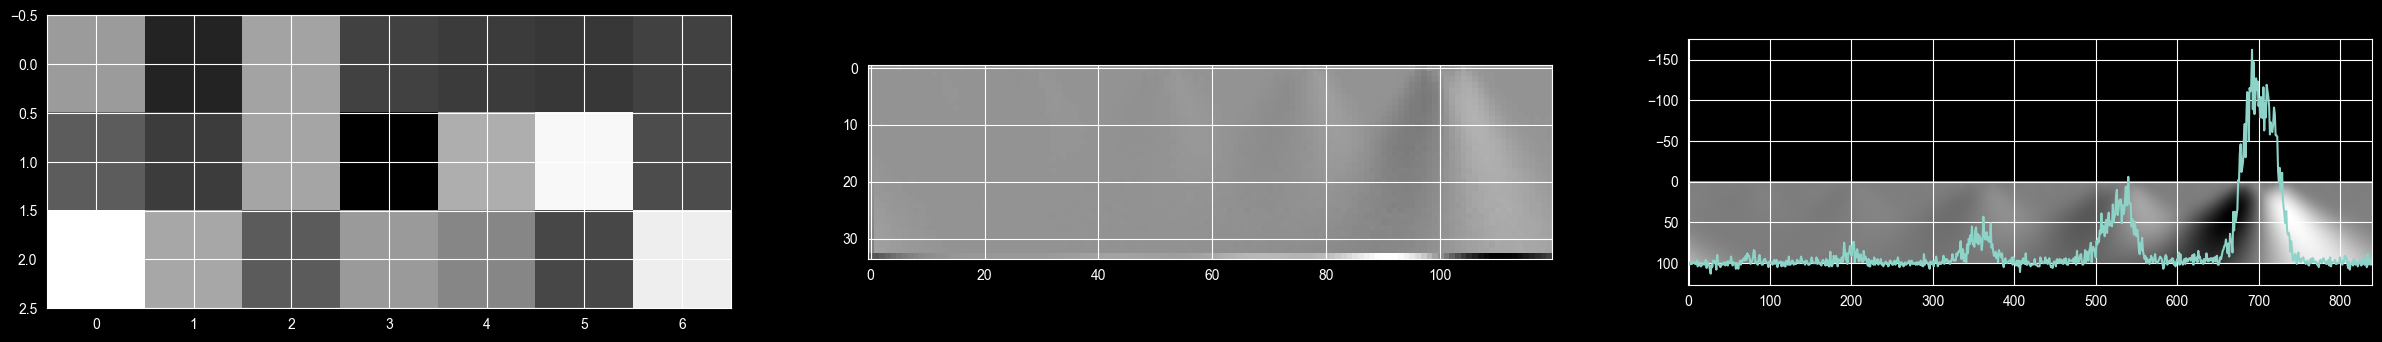

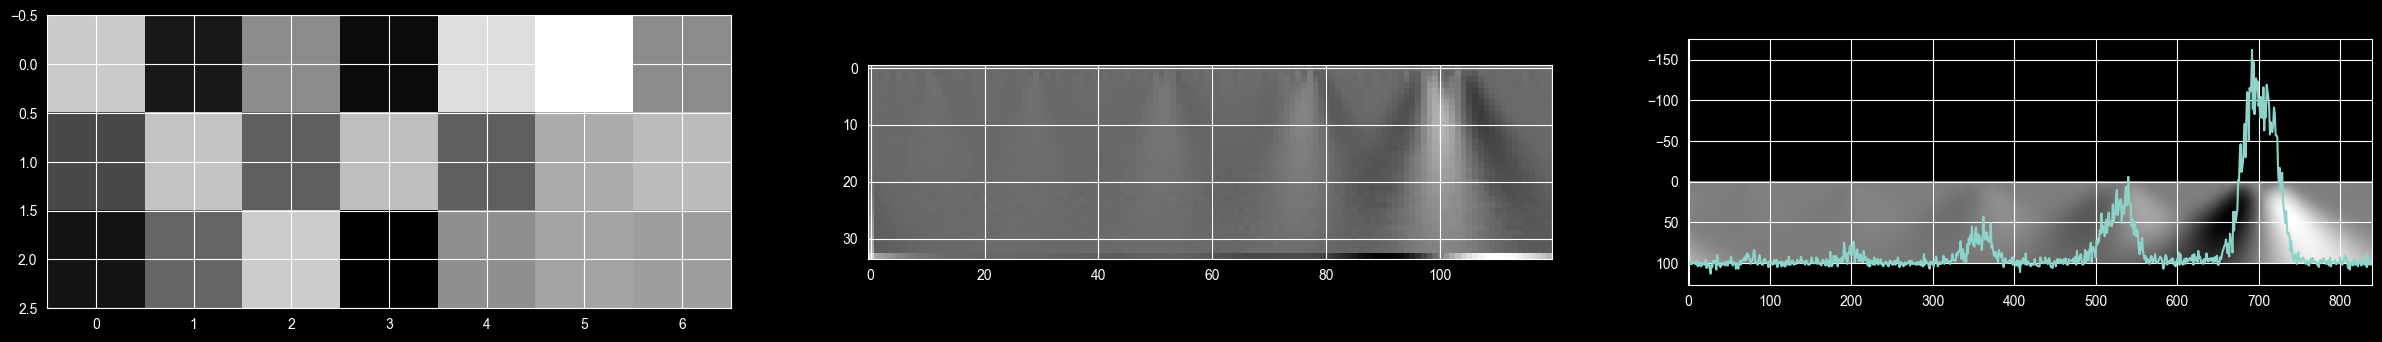

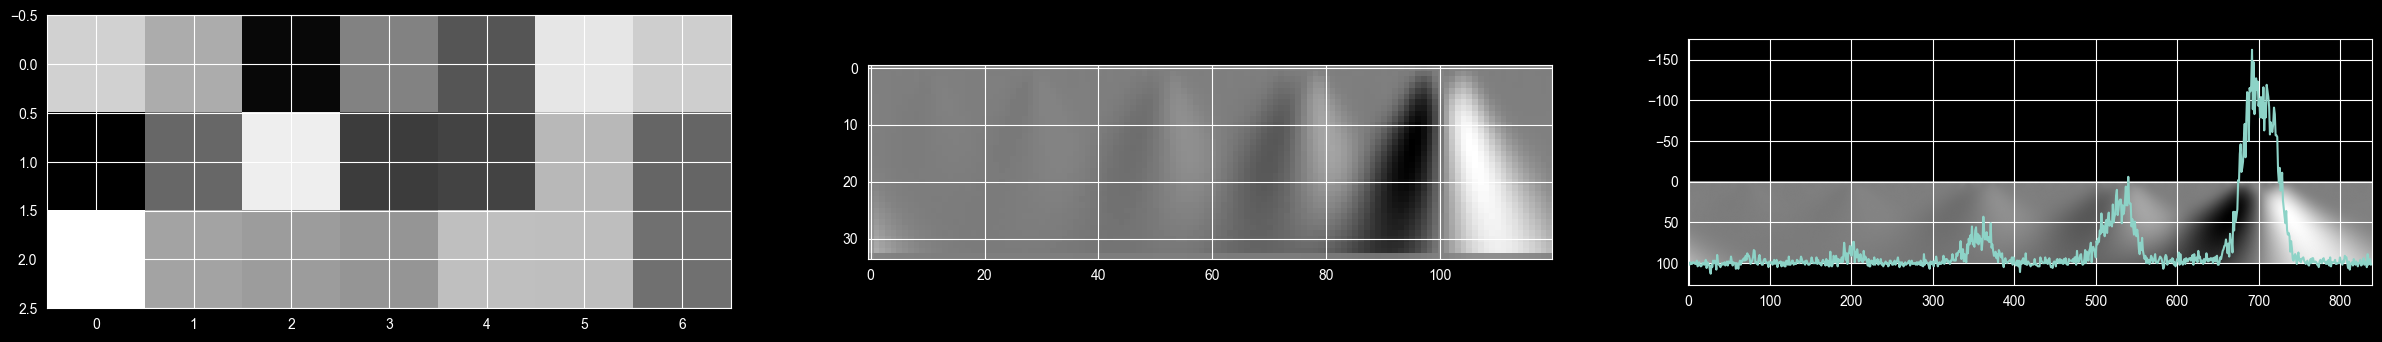

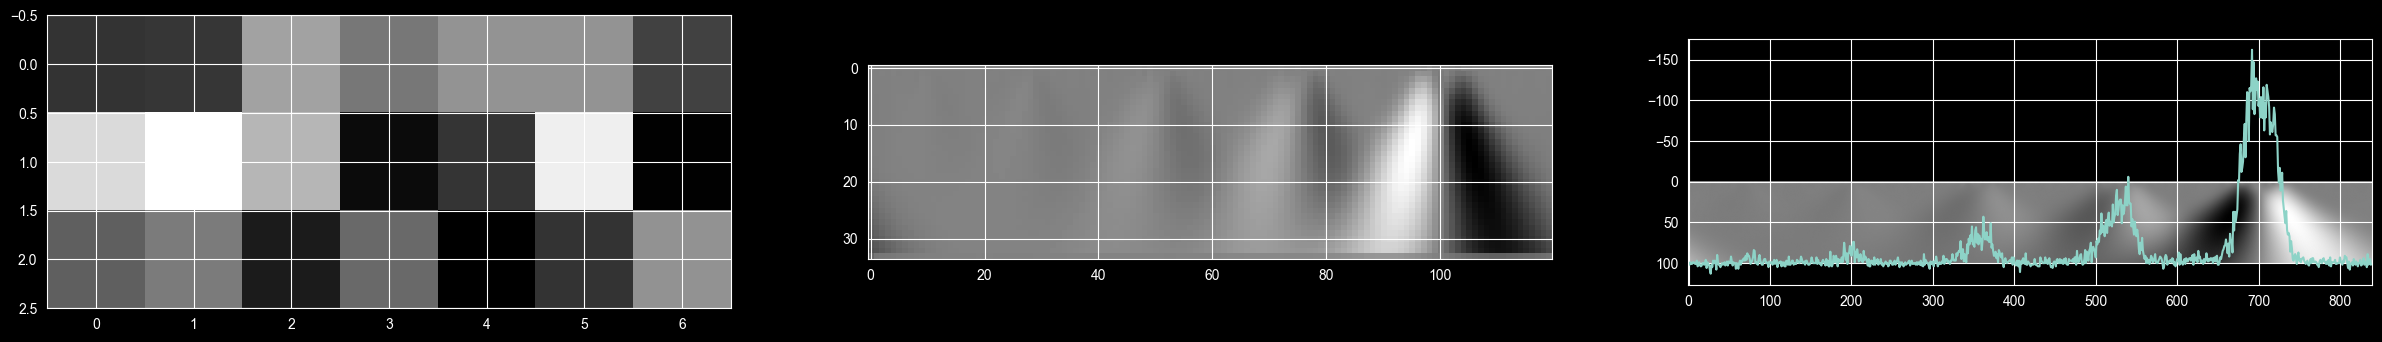

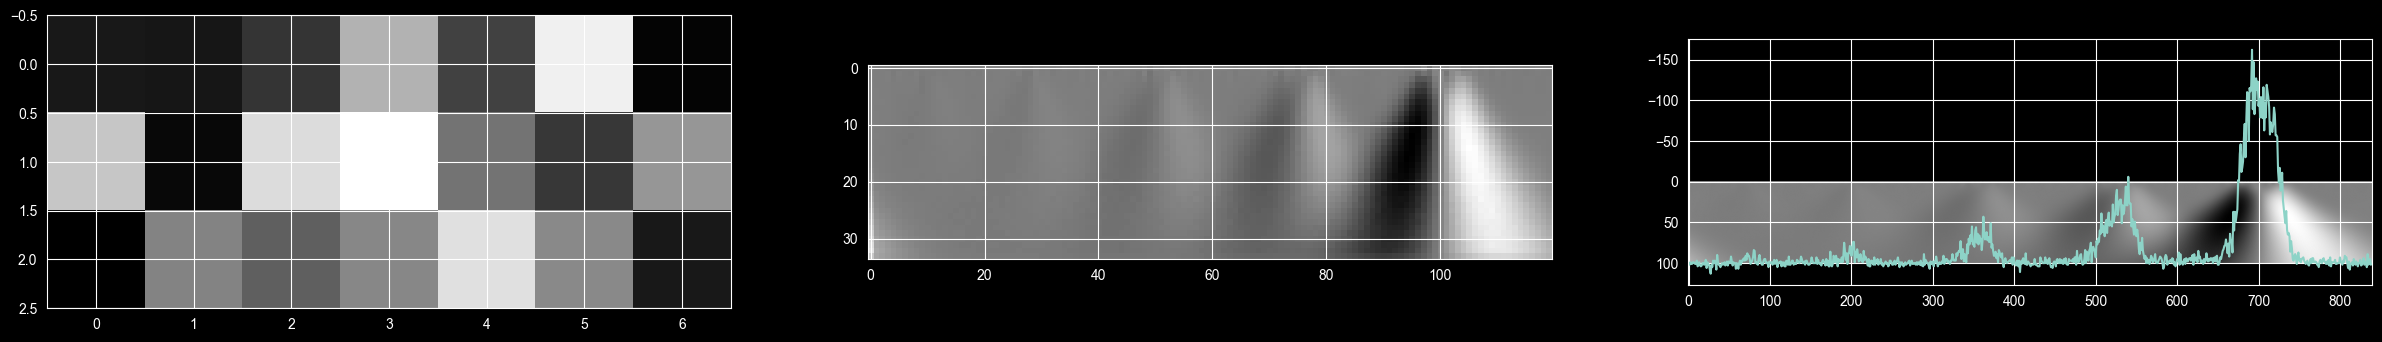

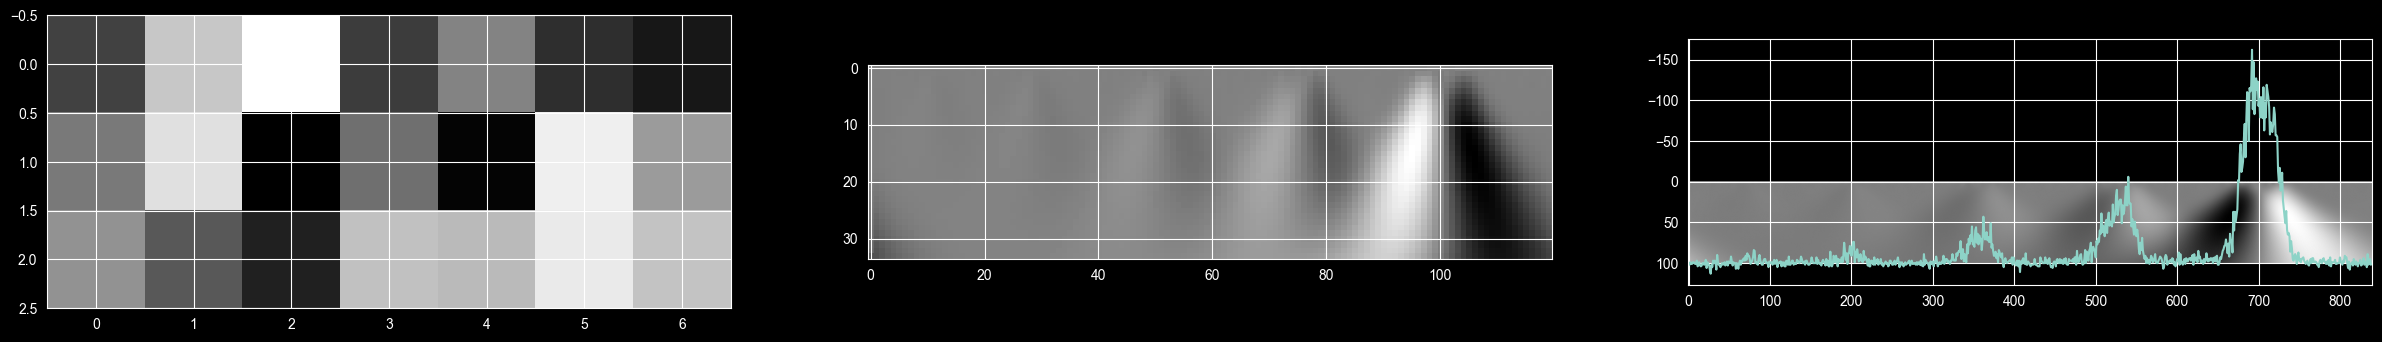

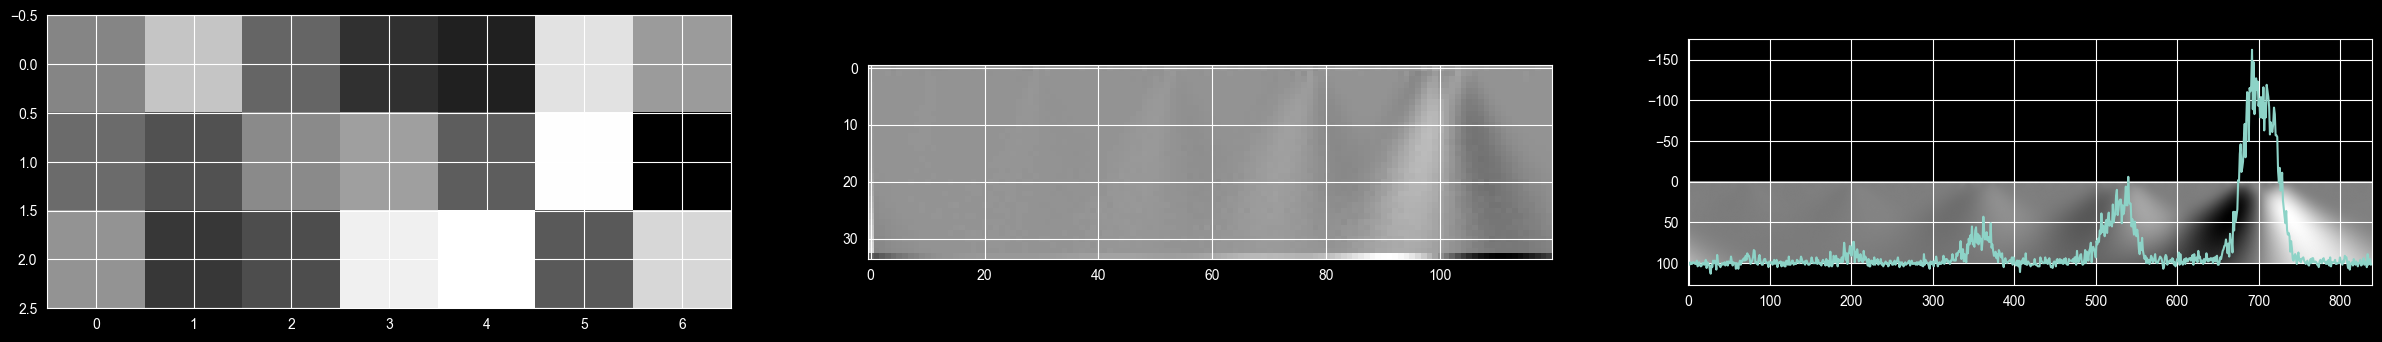

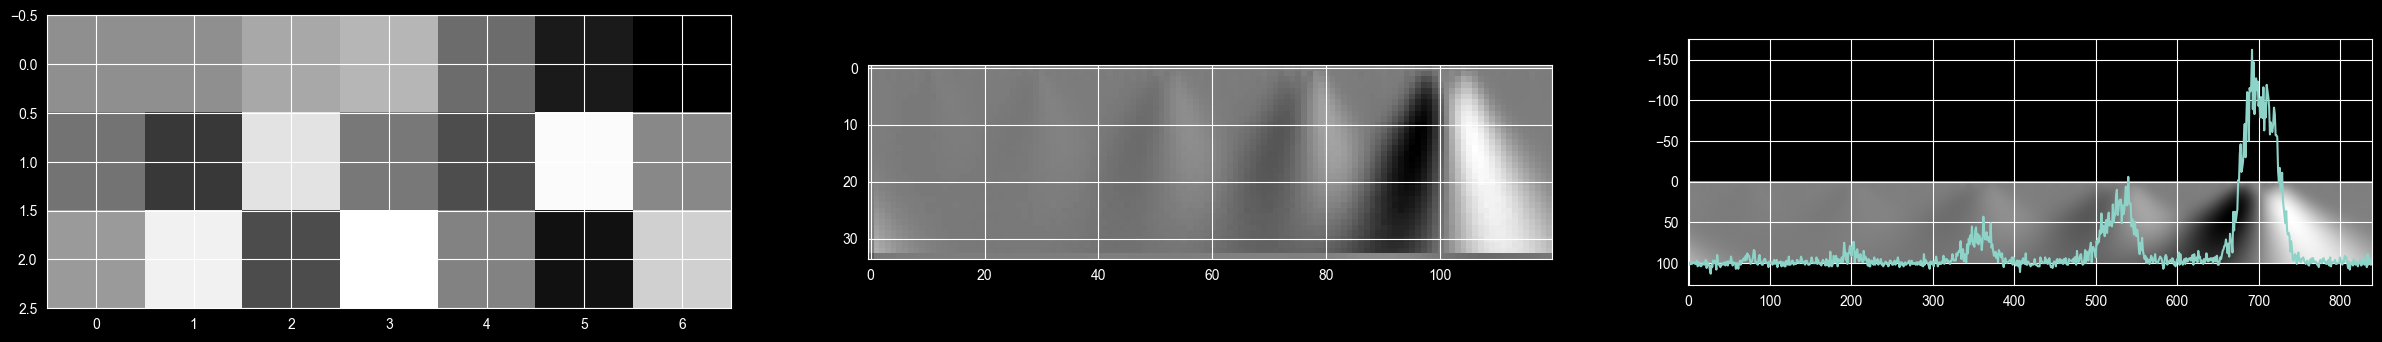

In [65]:

for i in range(result_convolution.shape[0]):
    fig, ax  = plt.subplots(1, 3, figsize=(30,10))
    ax[0].imshow(weights[i,0].detach().numpy(), cmap='gray')
    ax[1].imshow(result_convolution[i].detach().numpy(), cmap='gray')
    ax[2].imshow(coef.detach().numpy(), cmap='gray')
    ax[2].plot(signal.detach().numpy()*(-1) + 200)



In [66]:
pre_pre_conv = model.backbone.wavelet_attention_block.convolution[1]
pre_conv = model.backbone.wavelet_attention_block.convolution[2]
conv_layer = model.backbone.wavelet_attention_block.convolution[3]
result_convolution = conv_layer(pre_conv(pre_pre_conv(result_convolution)))
weights = conv_layer.weight

print(f'Форма карт признаков после второго слоя: {result_convolution.shape} Форма весов: {weights.shape}, ')

Форма карт признаков после второго слоя: torch.Size([16, 6, 12]) Форма весов: torch.Size([16, 8, 3, 5]), 


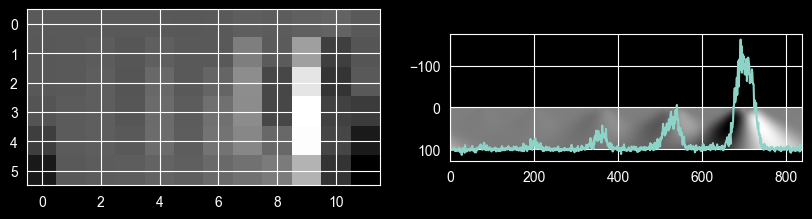

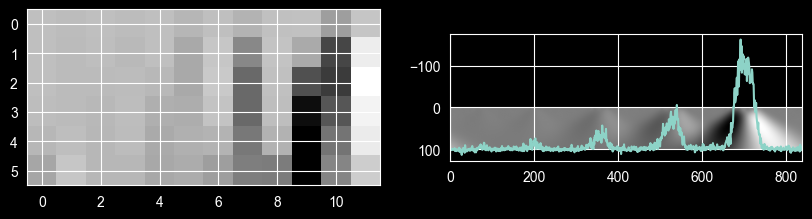

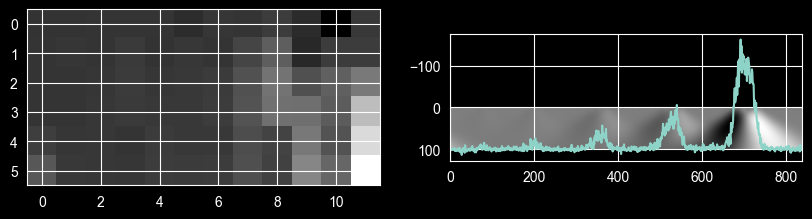

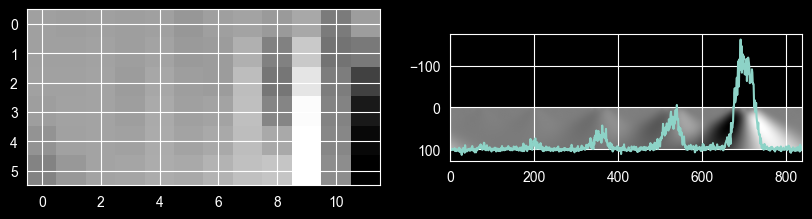

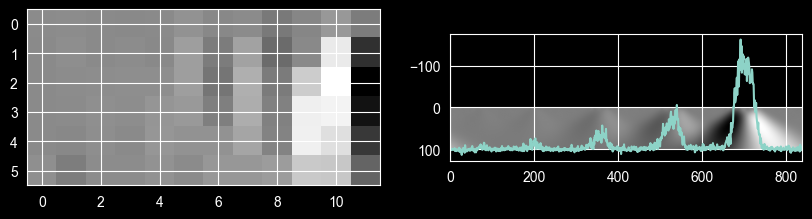

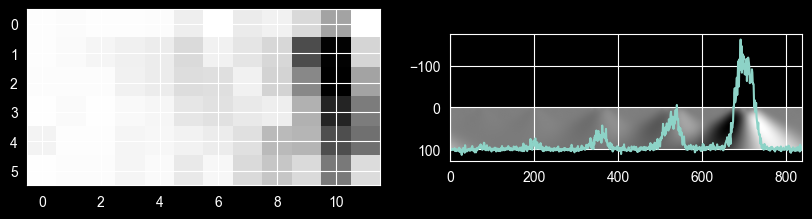

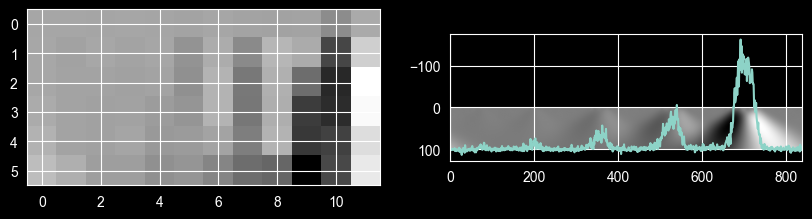

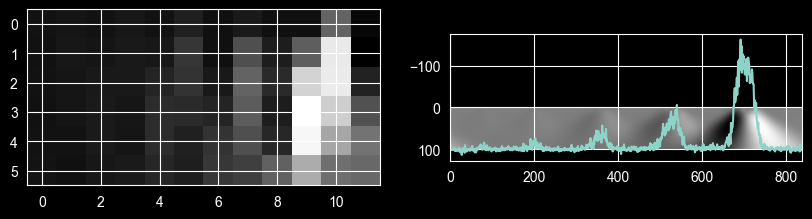

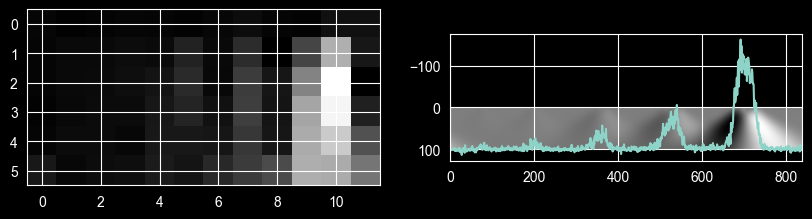

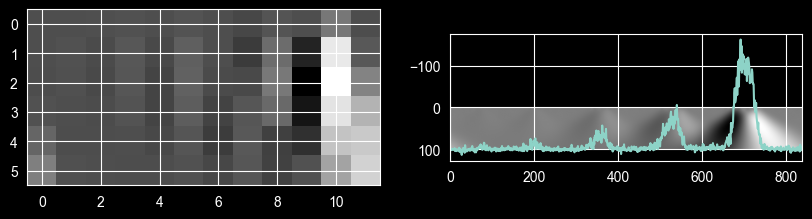

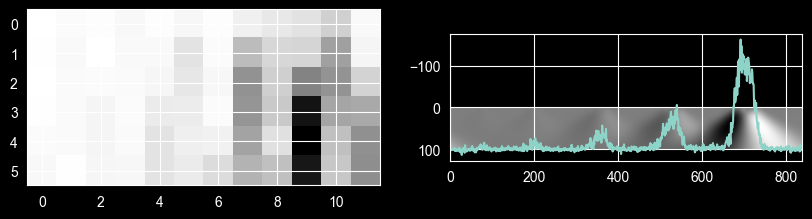

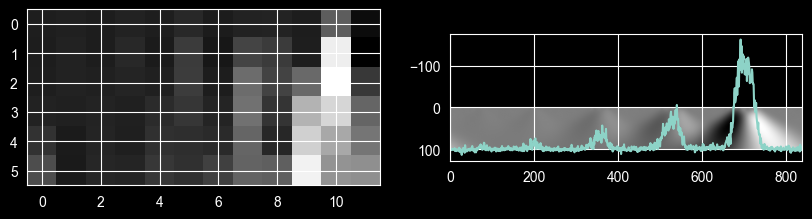

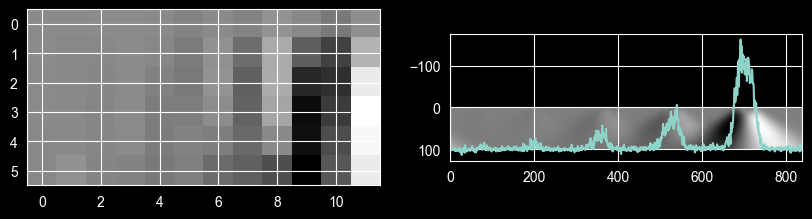

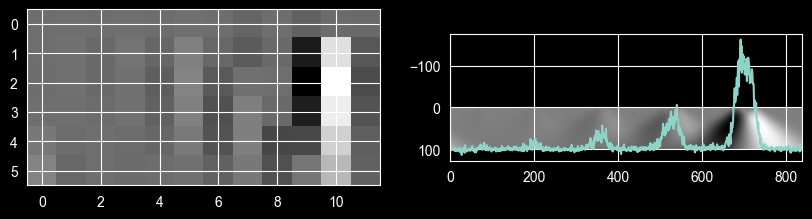

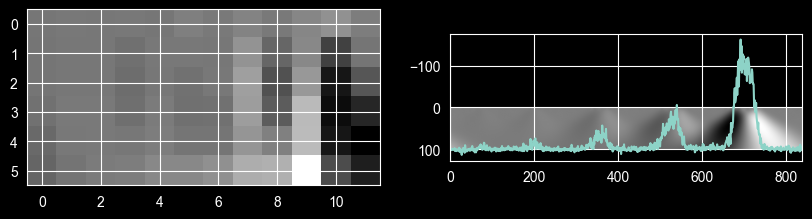

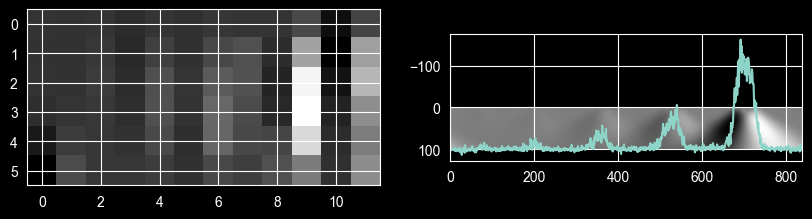

In [67]:

for i in range(result_convolution.shape[0]):
    fig, ax  = plt.subplots(1, 2, figsize=(10,5))
    ax[0].imshow(result_convolution[i].detach().numpy(), cmap='gray')
    ax[1].imshow(coef.detach().numpy(), cmap='gray')
    ax[1].plot(signal.detach().numpy()*(-1) + 200)



In [68]:
pre_pre_conv = model.backbone.wavelet_attention_block.convolution[4]
pre_conv = model.backbone.wavelet_attention_block.convolution[5]
conv_layer = model.backbone.wavelet_attention_block.convolution[6]
result_convolution = conv_layer(pre_conv(pre_pre_conv(result_convolution)))
weights = conv_layer.weight

print(f'Форма карт признаков после третьего слоя: {result_convolution.shape} Форма весов: {weights.shape}, ')

Форма карт признаков после третьего слоя: torch.Size([32, 3, 6]) Форма весов: torch.Size([32, 16, 3, 3]), 


C:\Users\supervisor.LTCPC-280426-01\AppData\Local\Temp\ipykernel_13256\309209142.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax  = plt.subplots(1, 2, figsize=(15,7))


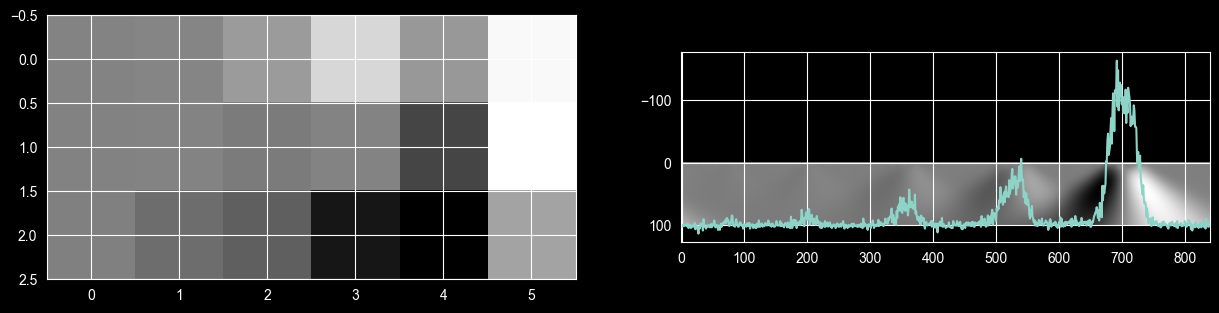

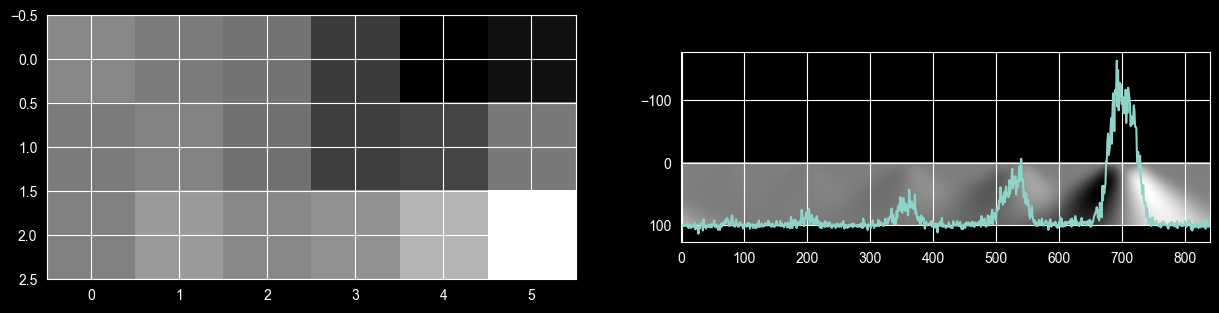

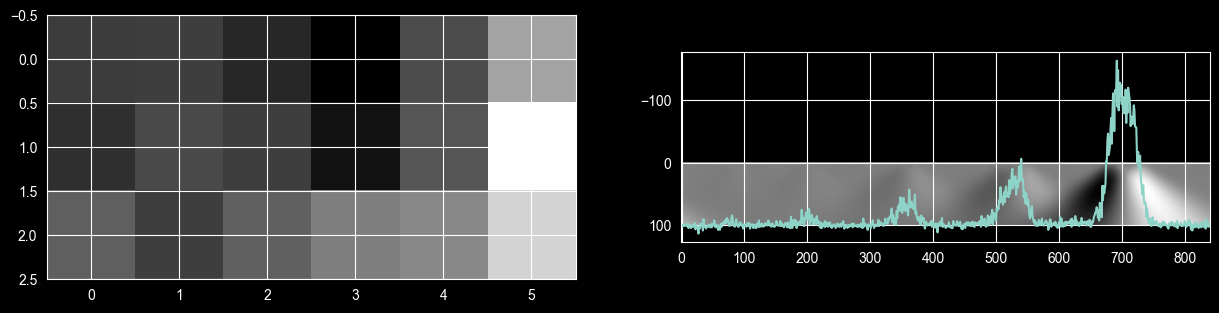

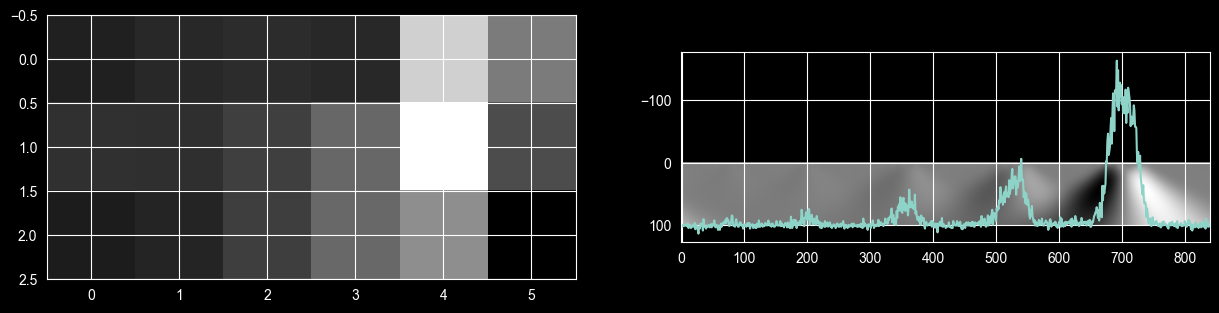

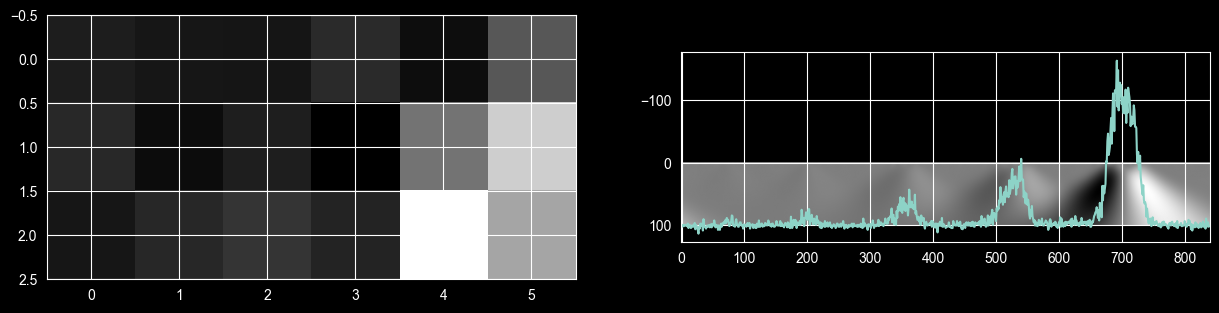

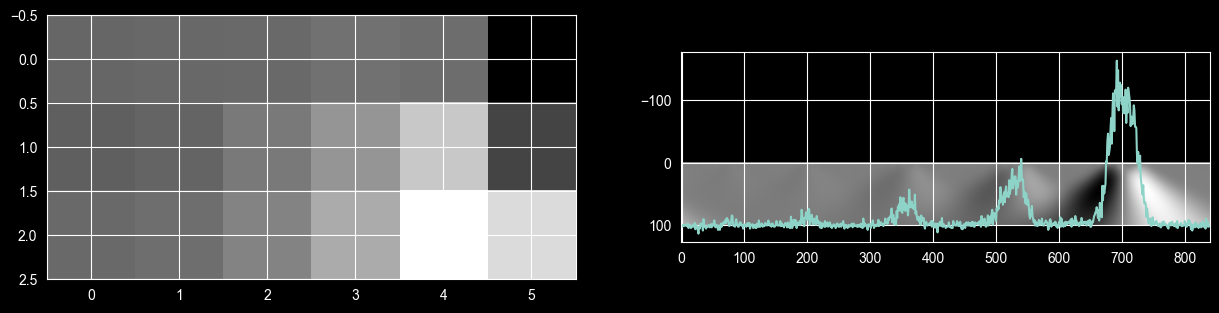

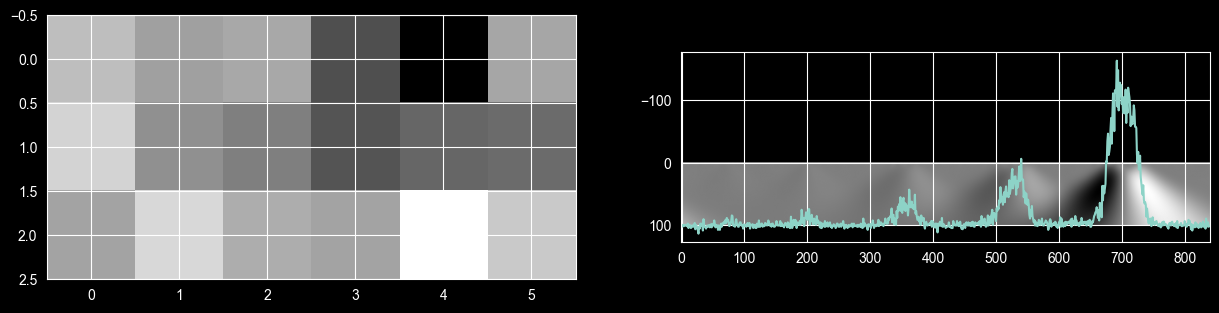

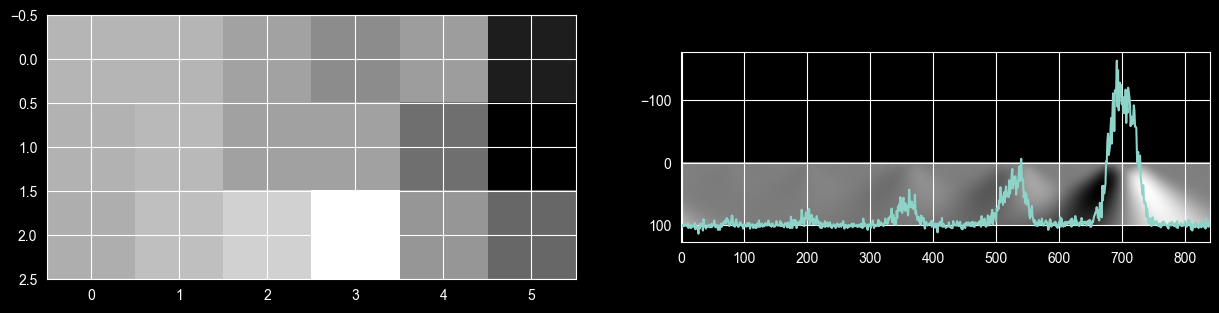

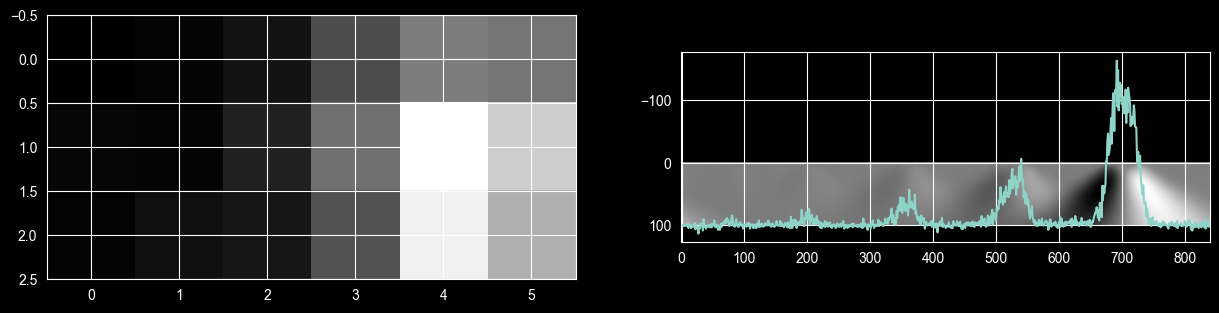

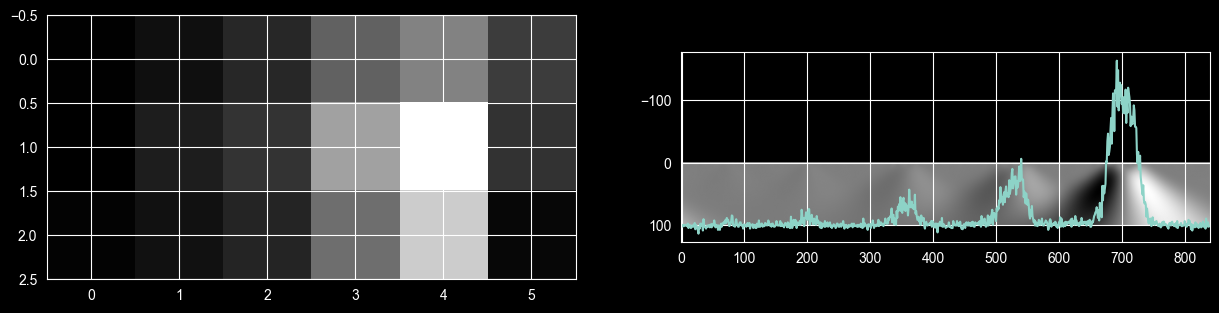

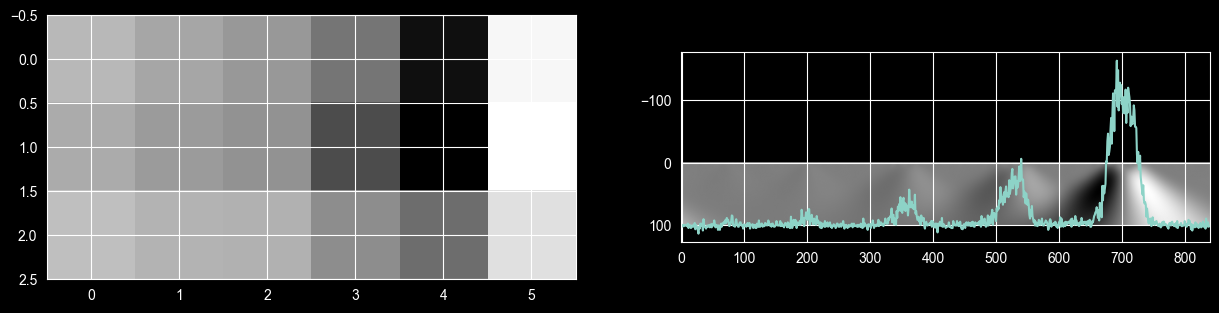

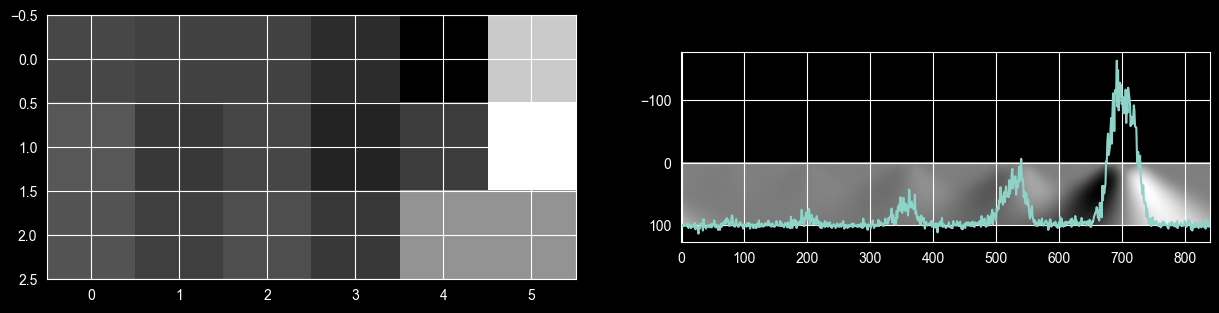

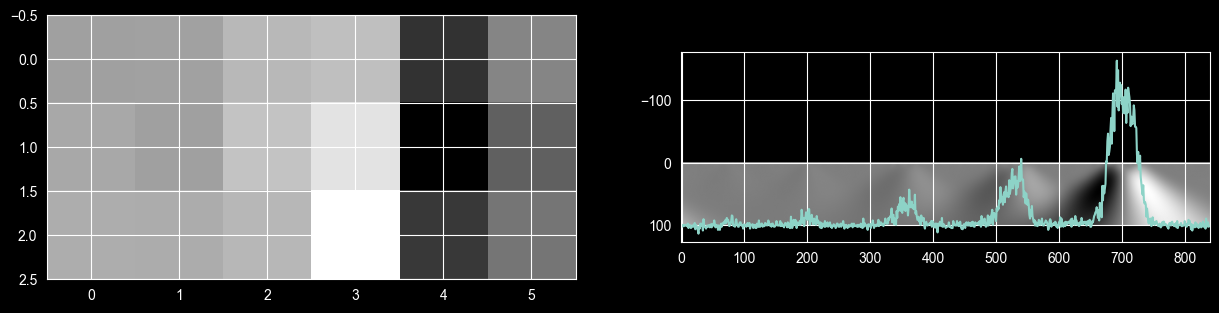

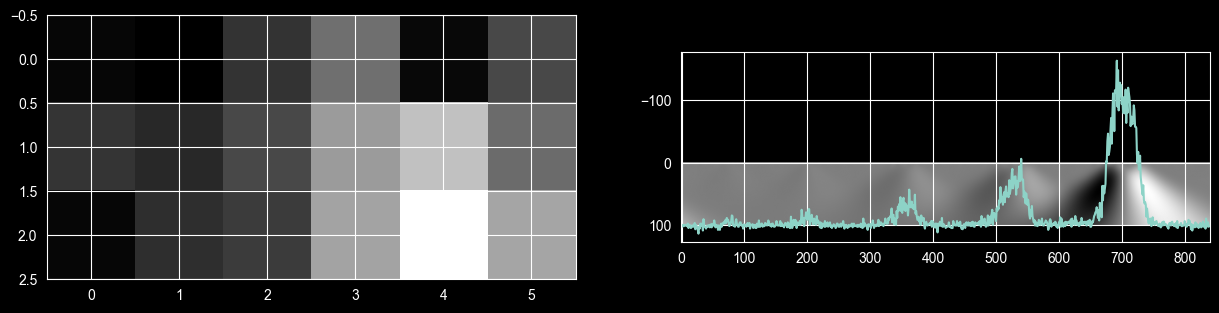

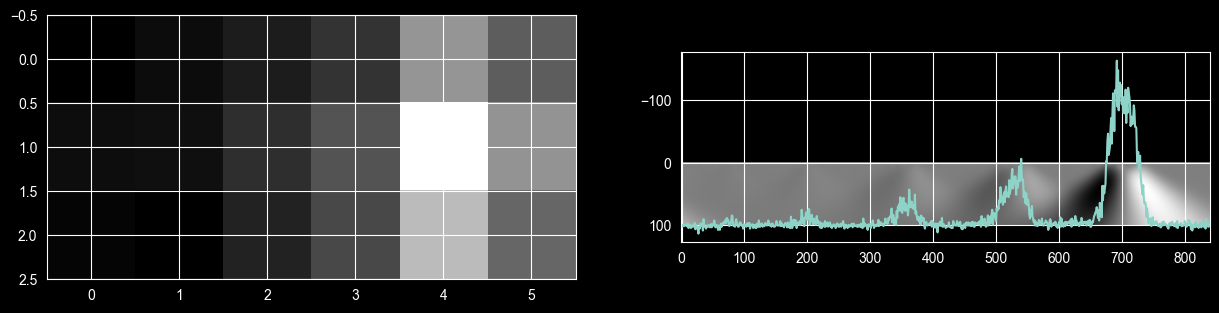

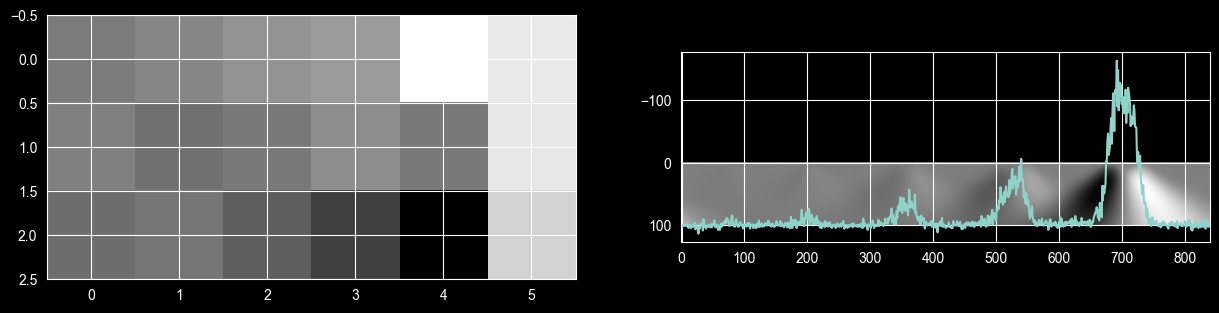

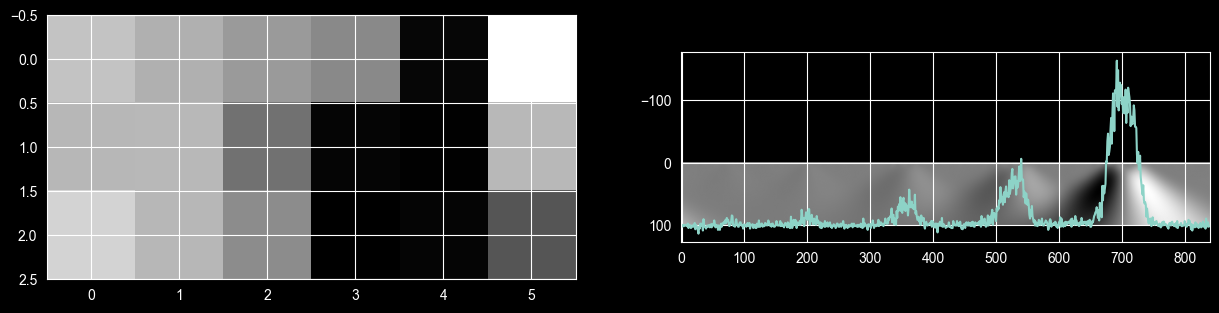

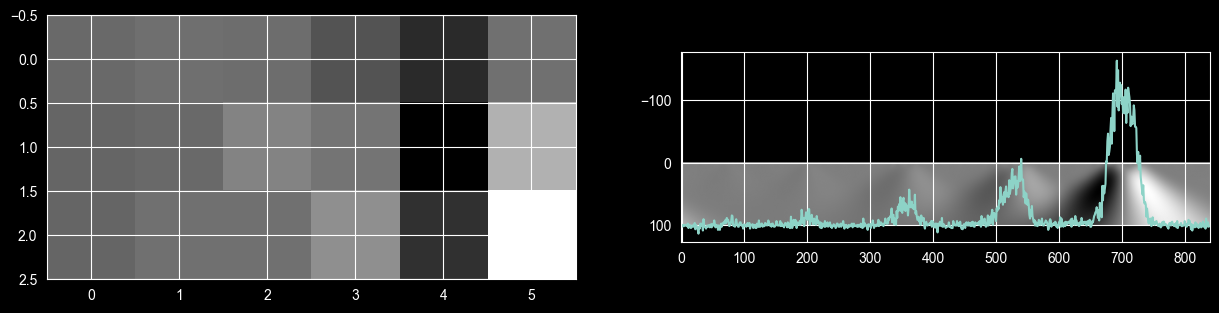

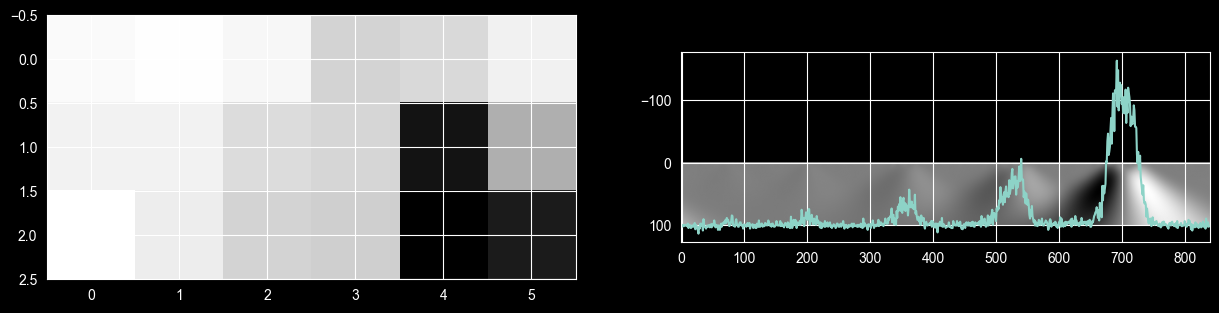

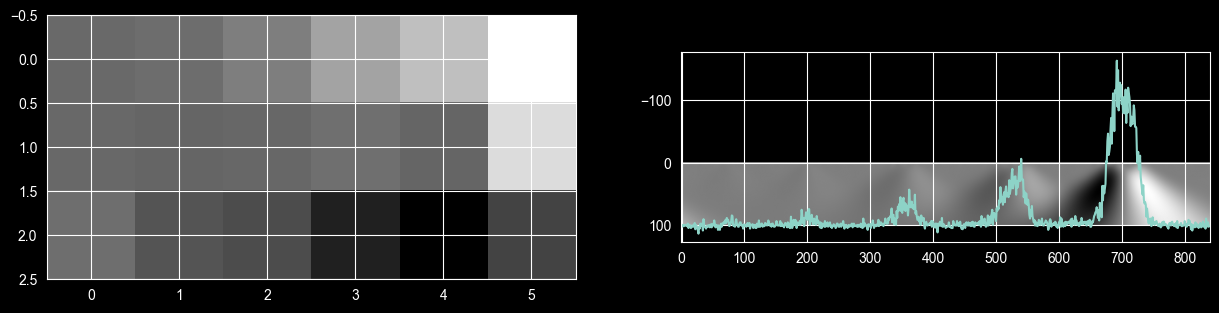

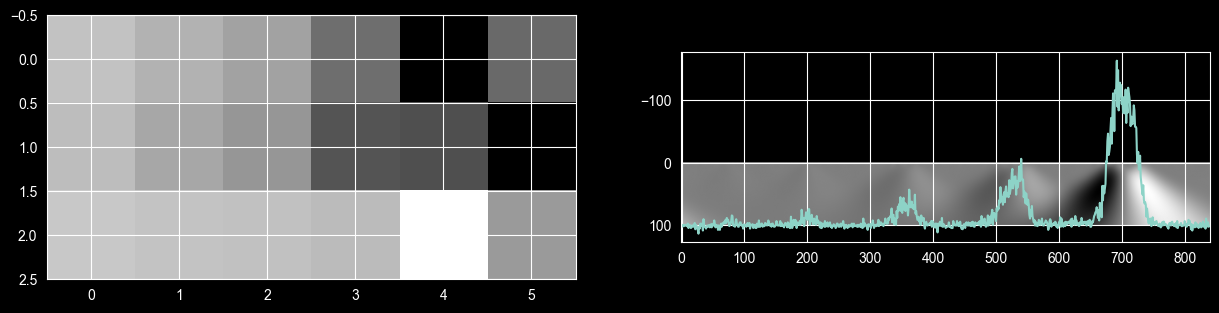

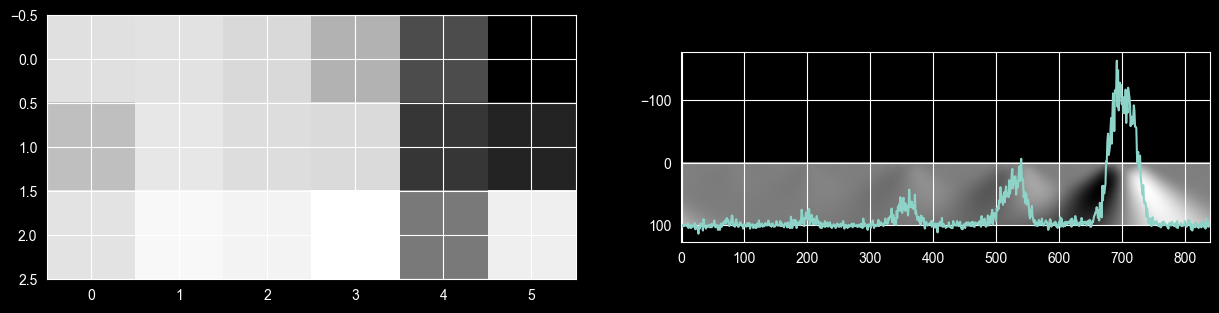

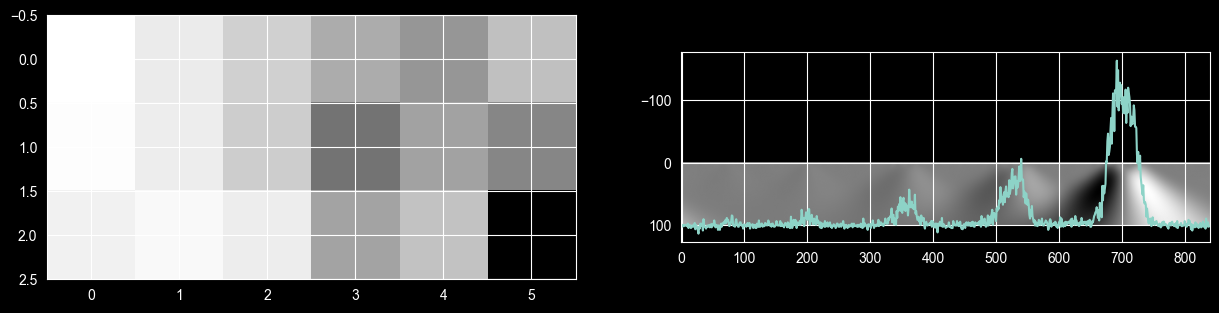

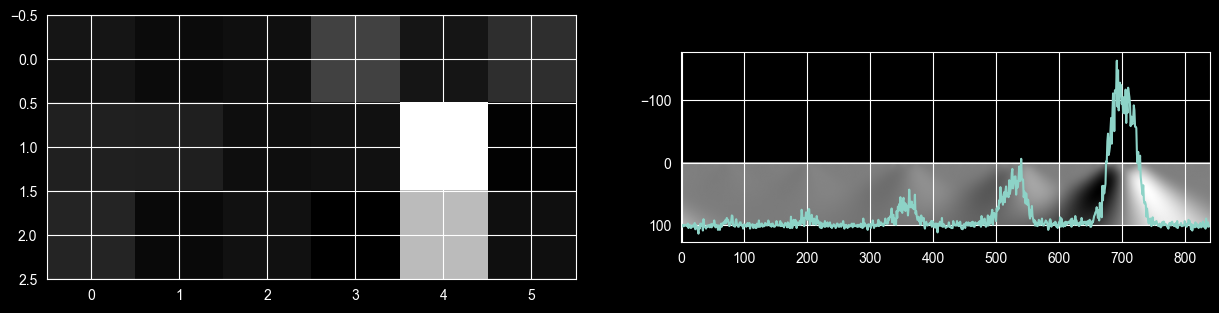

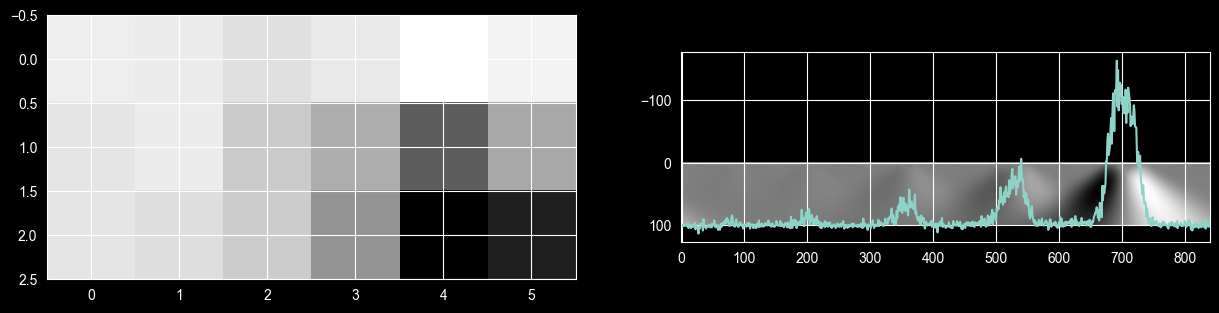

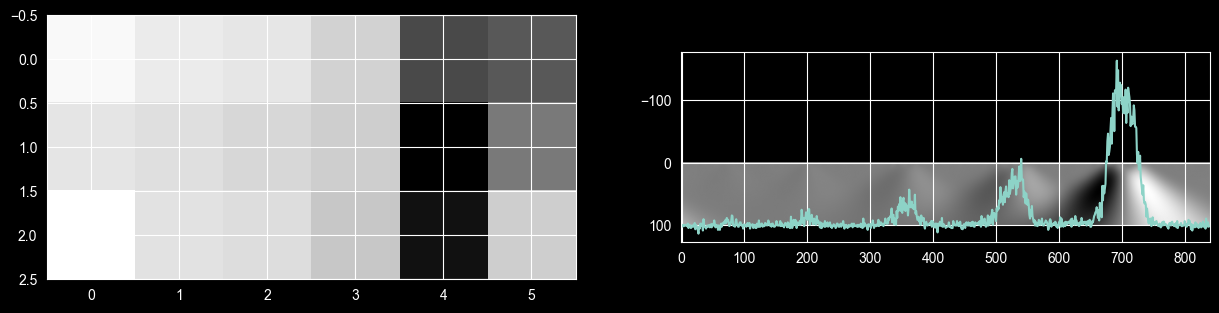

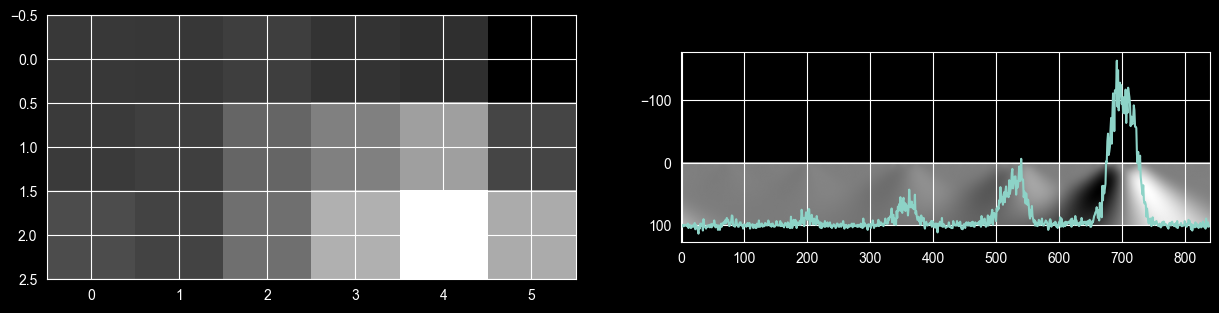

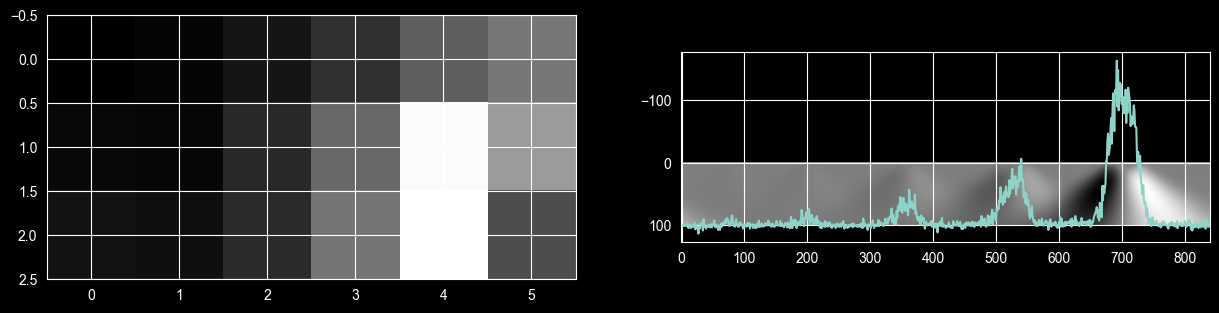

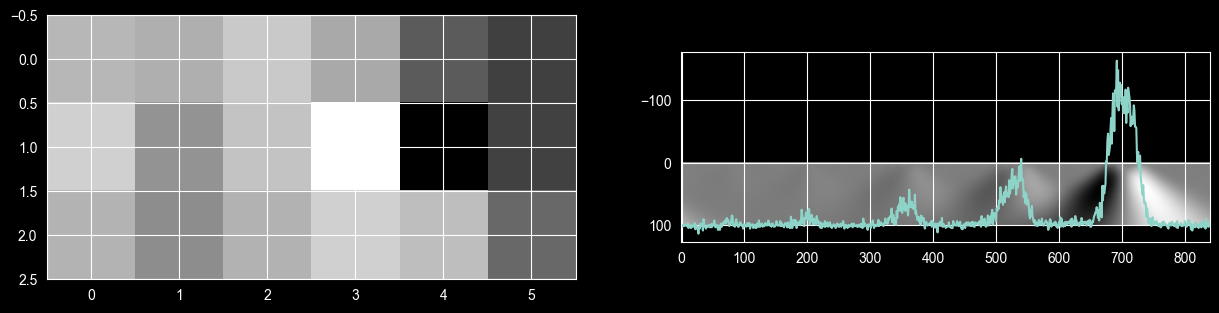

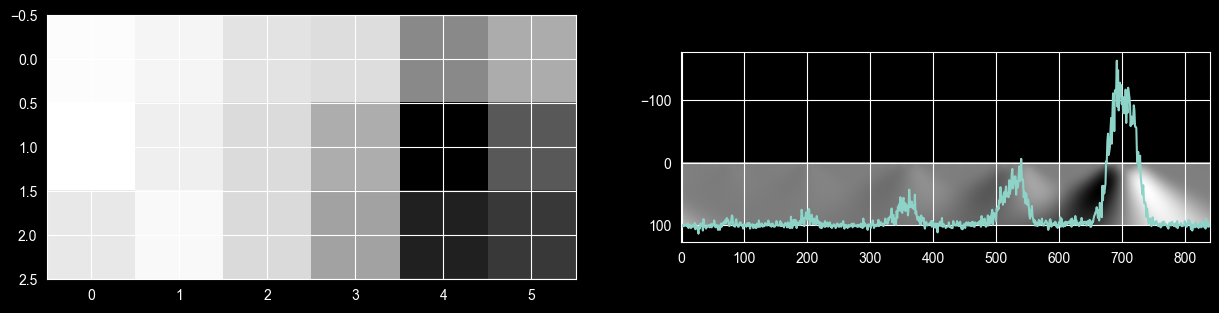

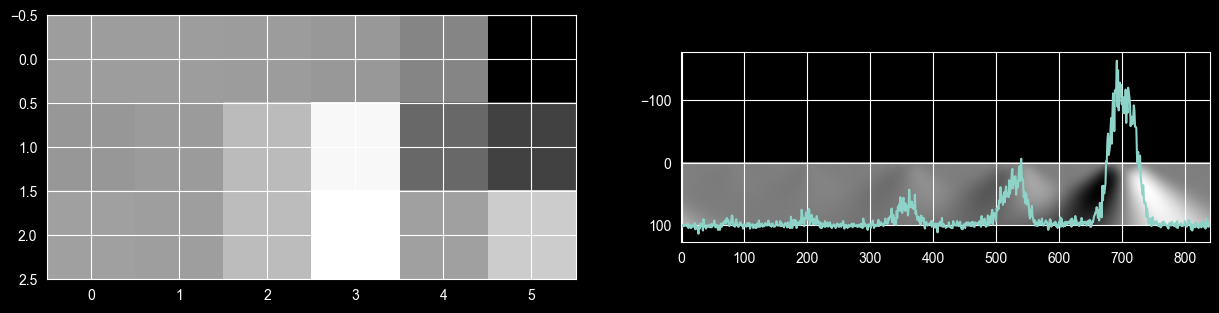

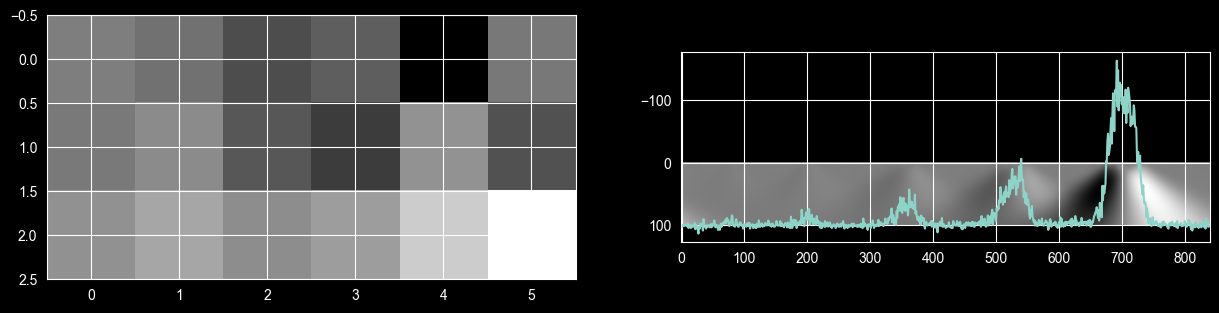

In [69]:

for i in range(result_convolution.shape[0]):
    fig, ax  = plt.subplots(1, 2, figsize=(15,7))
    ax[0].imshow(result_convolution[i].detach().numpy(), cmap='gray')
    ax[1].imshow(coef.detach().numpy(), cmap='gray')
    ax[1].plot(signal.detach().numpy()*(-1) + 200)



Вывод: модель фактически уничтожает пространственную структуру вейвлета, что кажется огромной потерей информации.

конфиг:
    name: 'NeuroStreak_0.0.1'

    head:
      spectral_dim: 64
      wavelet_dim: 32
      embedding_dim: 128

    backbone:
      hidden_dim: 32
      num_heads: 8
      depth: 8

    embedding:
      wavelet: 'gaus1'
      max_amp: 101
      step: 1


Устройство слоя:
NeuroStreakBackbone(
  (wavelet_attention_block): WaveletAttentionBlock(
    (convolution): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 7), stride=(3, 7), padding=(1, 3))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(8, 16, kernel_size=(3, 5), stride=(3, 5), padding=(1, 2))
      (4): ReLU(inplace=True)
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU(inplace=True)
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (embedding_projection): Linear(in_features=1, out_features=1, bias=True)
    (cross_attention): ModuleList(
      (0-7): 8 x CrossAttention(
        (cross_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
      )
    )
  )
  (signal_attention_block): SpectralAttentionBlock(
    (cross_attention): ModuleList(
      (0-7): 8 x CrossAttention(
        (cross_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
      )
    )
    (features): Conv1d(1, 64, kernel_size=(11,), stride=(1,), padding=(5,))
  )
)